In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

In [2]:
import julia
from julia import Main
Main.eval("using QuadGK")

In [3]:
Main.include("..\\strong coupling\\constants.jl")
Main.include("..\\strong coupling\\alpha_s.jl")
Main.include("..\\anomalous dim\\cusp\\cusp.jl")
#Main.include("anomalous dim\\non-cusp\\gammaH.jl")
#Main.include("anomalous dim\\non-cusp\\gammaB.jl")
#Main.include("anomalous dim\\non-cusp\\gammaS.jl")
#Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("..\\hard\\hard.jl")
Main.include("..\\jet\\jet.jl")
Main.include("..\\soft\\soft.jl")

In [4]:
Q = np.linspace(5, 1000, 1000)
length = len(Q)

alpha_1 = np.zeros(length)
alpha_2 = np.zeros(length)
alpha_3 = np.zeros(length)
alpha_4 = np.zeros(length)
alpha_5 = np.zeros(length)

for index, q_value in enumerate(Q):
    alpha_1[index] = Main.alpha_s_func_pert(μf=float(q_value), μi=91.1876, αs=0.118, order = 0, nf=5)
    alpha_2[index] = Main.alpha_s_func_pert(μf=float(q_value), μi=91.1876, αs=0.118, order = 1, nf=5)
    alpha_3[index] = Main.alpha_s_func_pert(μf=float(q_value), μi=91.1876, αs=0.118, order = 2, nf=5)
    alpha_4[index] = Main.alpha_s_func_pert(μf=float(q_value), μi=91.1876, αs=0.118, order = 3, nf=5)
    alpha_5[index] = Main.alpha_s_func_pert(μf=float(q_value), μi=91.1876, αs=0.118, order = 4, nf=5)

alpha_1_numerical = np.zeros(length)
alpha_2_numerical = np.zeros(length)
alpha_3_numerical = np.zeros(length)
alpha_4_numerical = np.zeros(length)
alpha_5_numerical = np.zeros(length)

for index, q_value in enumerate(Q):
    alpha_1_numerical[index] = Main.alpha_s_func_numerical(μf=float(q_value), μi=91.1876, αs=0.118, order = 1)
    alpha_2_numerical[index] = Main.alpha_s_func_numerical(μf=float(q_value), μi=91.1876, αs=0.118, order = 2)
    alpha_3_numerical[index] = Main.alpha_s_func_numerical(μf=float(q_value), μi=91.1876, αs=0.118, order = 3)
    alpha_4_numerical[index] = Main.alpha_s_func_numerical(μf=float(q_value), μi=91.1876, αs=0.118, order = 4)
    alpha_5_numerical[index] = Main.alpha_s_func_numerical(μf=float(q_value), μi=91.1876, αs=0.118, order = 5)


In [5]:
alpha_1_schwartz = np.zeros(length)
alpha_2_schwartz = np.zeros(length)
alpha_3_schwartz = np.zeros(length)
alpha_4_schwartz = np.zeros(length)

for index, q_value in enumerate(Q):
    alpha_1_schwartz[index] = Main.alpha_s_func_schwartz(μf=float(q_value), μi=91.1876, αs=0.118, order = 1, nf=5)
    alpha_2_schwartz[index] = Main.alpha_s_func_schwartz(μf=float(q_value), μi=91.1876, αs=0.118, order = 2, nf=5)
    alpha_3_schwartz[index] = Main.alpha_s_func_schwartz(μf=float(q_value), μi=91.1876, αs=0.118, order = 3, nf=5)

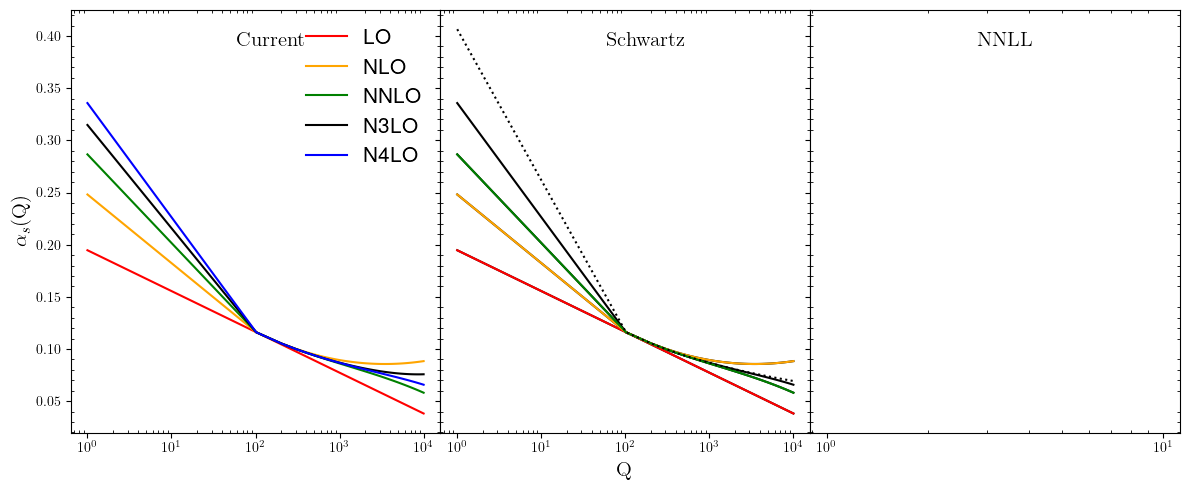

In [18]:
fig, [ax1,ax2,ax3] = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(Q, alpha_1, label="LO",color="red")
ax1.plot(Q, alpha_2, label="NLO",color="orange")
ax1.plot(Q, alpha_3, label="NNLO",color="green")
ax1.plot(Q, alpha_4, label="N3LO",color="black")
ax1.plot(Q, alpha_5, label="N4LO",color="blue")

#ax1.plot(Q, alpha_1_numerical, linestyle=':',color="red")
#ax1.plot(Q, alpha_2_numerical, linestyle=':',color="orange")
#ax1.plot(Q, alpha_3_numerical, linestyle=':',color="green")
#ax1.plot(Q, alpha_4_numerical, linestyle=':',color="black")

ax2.plot(Q, alpha_1, label="LO",color="black")
ax2.plot(Q, alpha_2, label="NLO",color="black")
ax2.plot(Q, alpha_3, label="NNLO",color="black")
ax2.plot(Q, alpha_5, label="N4LO",color="black")
ax2.plot(Q, alpha_1_schwartz, label="LO",color="red")
ax2.plot(Q, alpha_2_schwartz, label="NLO",color="orange")
ax2.plot(Q, alpha_3_schwartz, label="NNLO",color="green")

#ax2.plot(Q, alpha_1_numerical, linestyle=':',color="red")
#ax2.plot(Q, alpha_2_numerical, linestyle=':',color="orange")
#ax2.plot(Q, alpha_3_numerical, linestyle=':',color="green")
ax2.plot(Q, alpha_4_numerical, linestyle=':',color="black")

ax2.set_xlabel(r"\rm $\mathrm{Q}$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\alpha_s(\mathrm{Q})$",fontsize=sizeOfFont)
ax1.set_xscale('log')  
ax2.set_xscale('log')
ax3.set_xscale('log')   

ax1.minorticks_on()
ax2.minorticks_on()

ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax2.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax3.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)

props = dict(boxstyle='round', facecolor='white', alpha=0)

ax1.text(0.45, 0.95,  r"\rm Current", transform=ax1.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)
ax2.text(0.45, 0.95,  r"\rm Schwartz", transform=ax2.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)
ax3.text(0.45, 0.95,  r"\rm NNLL", transform=ax3.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)

ax1.legend(loc='upper right', frameon=False, fontsize=sizeOfFont)

#plt.ylim(-0.1,0.5)
#plt.xlim(1,10000)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

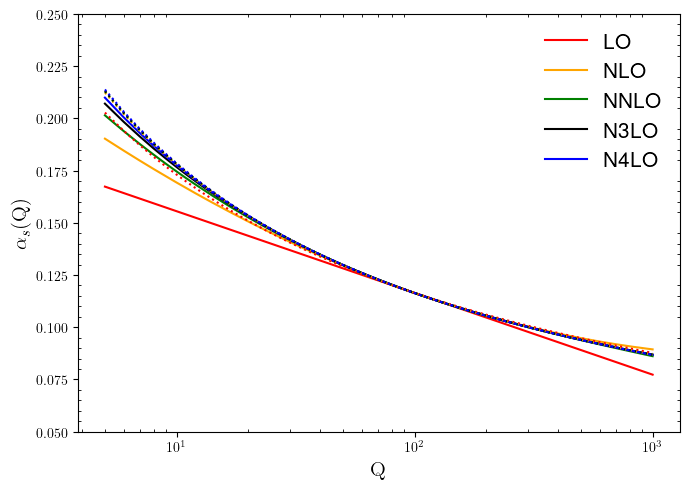

In [56]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5), sharey=True)

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(Q, alpha_1, label="LO",color="red")
ax1.plot(Q, alpha_2, label="NLO",color="orange")
ax1.plot(Q, alpha_3, label="NNLO",color="green")
ax1.plot(Q, alpha_4, label="N3LO",color="black")
ax1.plot(Q, alpha_5, label="N4LO",color="blue")

ax1.plot(Q, alpha_1_numerical, linestyle=':',color="red")
ax1.plot(Q, alpha_2_numerical, linestyle=':',color="orange")
ax1.plot(Q, alpha_3_numerical, linestyle=':',color="green")
ax1.plot(Q, alpha_4_numerical, linestyle=':',color="black")
ax1.plot(Q, alpha_5_numerical, linestyle=':',color="blue")

ax1.set_xlabel(r"\rm $\mathrm{Q}$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\alpha_s(\mathrm{Q})$",fontsize=sizeOfFont)
ax1.set_xscale('log')   

ax1.minorticks_on()

ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)

props = dict(boxstyle='round', facecolor='white', alpha=0)

#ax1.text(0.45, 0.95,  r"\rm Current", transform=ax1.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)

ax1.legend(loc='upper right', frameon=False, fontsize=sizeOfFont)

plt.ylim(0.05,0.25)
#plt.xlim(1,10000)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

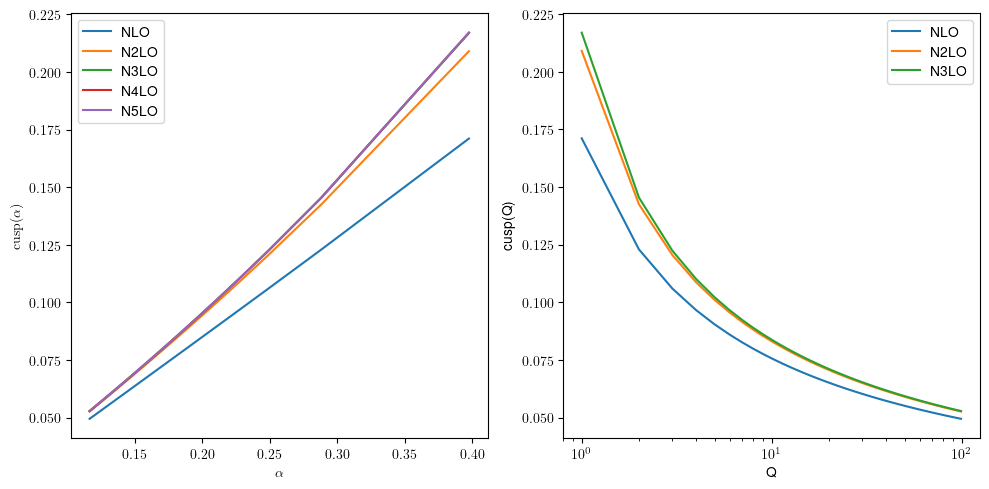

In [8]:
length = len(alpha_4)
cusp_1 = np.zeros(length)
cusp_2 = np.zeros(length)
cusp_3 = np.zeros(length)
cusp_4 = np.zeros(length)
cusp_5 = np.zeros(length)

for index, alpha_value in enumerate(alpha_4):
    cusp_1[index] = Main.Γ_func(αs=float(alpha_value), order=1, nf=5)
    cusp_2[index] = Main.Γ_func(αs=float(alpha_value), order=2, nf=5)
    cusp_3[index] = Main.Γ_func(αs=float(alpha_value), order=3, nf=5)
    cusp_4[index] = Main.Γ_func(αs=float(alpha_value), order=4, nf=5)
    cusp_5[index] = Main.Γ_func(αs=float(alpha_value), order=5, nf=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) 

ax1.plot(alpha_3, cusp_1, label="NLO")
ax1.plot(alpha_3, cusp_2, label="N2LO")
ax1.plot(alpha_3, cusp_3, label="N3LO")
ax1.plot(alpha_3, cusp_4, label="N4LO")
ax1.plot(alpha_3, cusp_5, label="N5LO")
ax1.set_xlabel(r"\rm $\alpha$")
ax1.set_ylabel(r"\rm cusp($\alpha$)")
ax1.legend()

ax2.plot(Q, cusp_1, label="NLO")
ax2.plot(Q, cusp_2, label="N2LO")
ax2.plot(Q, cusp_3, label="N3LO")
#ax2.plot(Q, cusp_4, label="N4LO")
#ax2.plot(Q, cusp_5, label="N4LO")
ax2.set_xlabel('Q')
ax2.set_ylabel('cusp(Q)')
ax2.set_xscale('log')  
ax2.legend()

plt.tight_layout()  
plt.show()

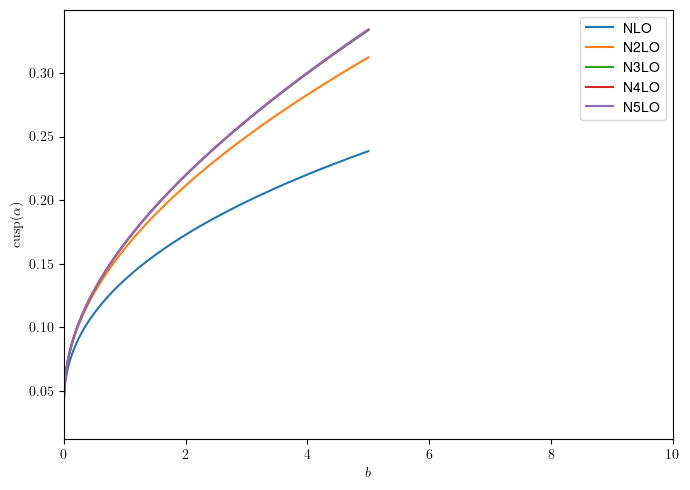

In [17]:
length = len(alpha_4)
cusp_1 = np.zeros(length)
cusp_2 = np.zeros(length)
cusp_3 = np.zeros(length)
cusp_4 = np.zeros(length)
cusp_5 = np.zeros(length)
b_list = np.linspace(10**(-4),5,length)
b0 = 1.12292

for index, bp in enumerate(b_list):
    cusp_1[index] = Main.Γ_final(μ=b0/bp, μ_ini=91.2, αs_ini=0.118, order=1, nf=5)
    cusp_2[index] = Main.Γ_final(μ=b0/bp, μ_ini=91.2, αs_ini=0.118, order=2, nf=5)
    cusp_3[index] = Main.Γ_final(μ=b0/bp, μ_ini=91.2, αs_ini=0.118, order=3, nf=5)
    cusp_4[index] = Main.Γ_final(μ=b0/bp, μ_ini=91.2, αs_ini=0.118, order=4, nf=5)
    cusp_5[index] = Main.Γ_final(μ=b0/bp, μ_ini=91.2, αs_ini=0.118, order=5, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

ax1.plot(b_list, cusp_1, label="NLO")
ax1.plot(b_list, cusp_2, label="N2LO")
ax1.plot(b_list, cusp_3, label="N3LO")
ax1.plot(b_list, cusp_4, label="N4LO")
ax1.plot(b_list, cusp_5, label="N5LO")
ax1.set_xlabel(r"\rm $b$")
ax1.set_ylabel(r"\rm cusp($\alpha$)")
ax1.legend()

#ax2.plot(Q, cusp_1, label="NLO")
#ax2.plot(Q, cusp_2, label="N2LO")
#ax2.plot(Q, cusp_3, label="N3LO")
#ax2.plot(Q, cusp_4, label="N4LO")
#ax2.plot(Q, cusp_5, label="N4LO")
#ax2.set_xlabel('Q')
#ax2.set_ylabel('cusp(Q)')
#ax2.set_xscale('log')  
#ax2.legend()
plt.xlim(0.0,10)

plt.tight_layout()  
plt.show()

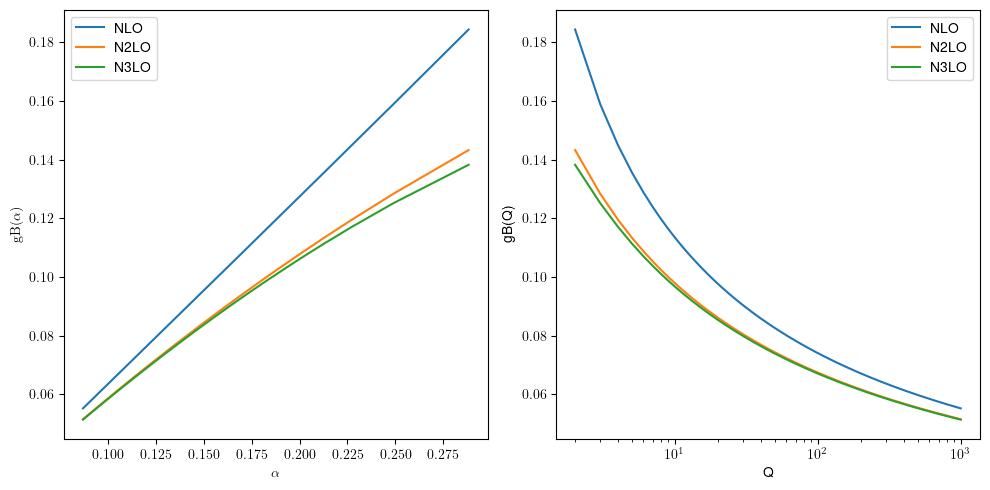

In [17]:
length = len(alpha_4)
γB_1 = np.zeros(length)
γB_2 = np.zeros(length)
γB_3 = np.zeros(length)

for index, alpha_value in enumerate(alpha_4):
    γB_1[index] = Main.γB_func(αs=float(alpha_value), order=1, nf=5)
    γB_2[index] = Main.γB_func(αs=float(alpha_value), order=2, nf=5)
    γB_3[index] = Main.γB_func(αs=float(alpha_value), order=3, nf=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) 

ax1.plot(alpha_3, γB_1, label="NLO")
ax1.plot(alpha_3, γB_2, label="N2LO")
ax1.plot(alpha_3, γB_3, label="N3LO")
ax1.set_xlabel(r"\rm $\alpha$")
ax1.set_ylabel(r"\rm gB($\alpha$)")
ax1.legend()

ax2.plot(Q, γB_1, label="NLO")
ax2.plot(Q, γB_2, label="N2LO")
ax2.plot(Q, γB_3, label="N3LO")
ax2.set_xlabel('Q')
ax2.set_ylabel('gB(Q)')
ax2.set_xscale('log')  
ax2.legend()

plt.tight_layout()  
plt.show()

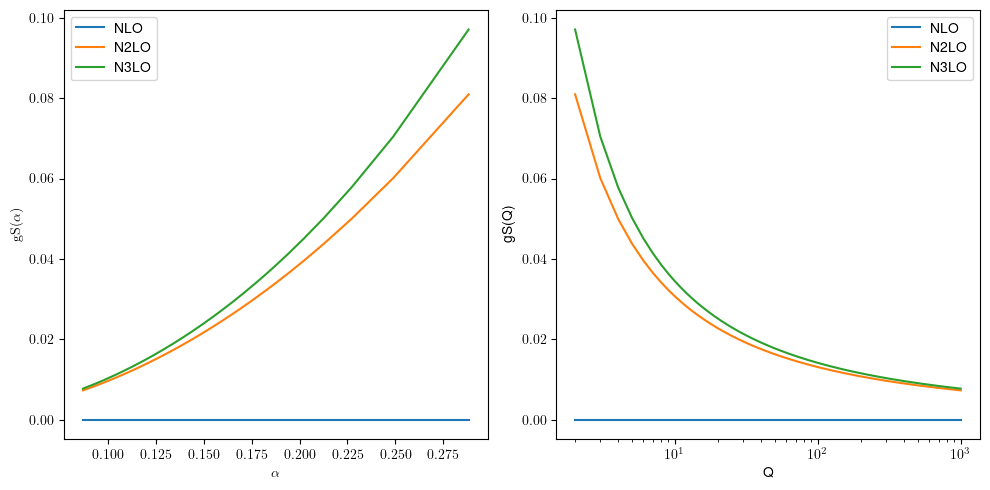

In [18]:
length = len(alpha_4)
γS_1 = np.zeros(length)
γS_2 = np.zeros(length)
γS_3 = np.zeros(length)

for index, alpha_value in enumerate(alpha_4):
    γS_1[index] = Main.γS_func(αs=float(alpha_value), order=1, nf=5)
    γS_2[index] = Main.γS_func(αs=float(alpha_value), order=2, nf=5)
    γS_3[index] = Main.γS_func(αs=float(alpha_value), order=3, nf=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) 

ax1.plot(alpha_3, γS_1, label="NLO")
ax1.plot(alpha_3, γS_2, label="N2LO")
ax1.plot(alpha_3, γS_3, label="N3LO")
ax1.set_xlabel(r"\rm $\alpha$")
ax1.set_ylabel(r"\rm gS($\alpha$)")
ax1.legend()

ax2.plot(Q, γS_1, label="NLO")
ax2.plot(Q, γS_2, label="N2LO")
ax2.plot(Q, γS_3, label="N3LO")
ax2.set_xlabel('Q')
ax2.set_ylabel('gS(Q)')
ax2.set_xscale('log')  
ax2.legend()

plt.tight_layout()  
plt.show()

In [13]:
length = len(alpha_4)
γν_1 = np.zeros(length)
γν_2 = np.zeros(length)
γν_3 = np.zeros(length)

for index, alpha_value in enumerate(alpha_4):
    γν_1[index] = Main.γν_func(αs=float(alpha_value), order=1, nf=5)
    γν_2[index] = Main.γν_func(αs=float(alpha_value), order=2, nf=5)
    γν_3[index] = Main.γν_func(αs=float(alpha_value), order=3, nf=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) 

ax1.plot(alpha_3, γν_1, label="NLO")
ax1.plot(alpha_3, γν_2, label="N2LO")
ax1.plot(alpha_3, γν_3, label="N3LO")
ax1.set_xlabel(r"\rm $\alpha$")
ax1.set_ylabel(r"\rm gv($\alpha$)")
ax1.legend()

ax2.plot(Q, γν_1, label="NLO")
ax2.plot(Q, γν_2, label="N2LO")
ax2.plot(Q, γν_3, label="N3LO")
ax2.set_xlabel('Q')
ax2.set_ylabel('gv(Q)')
ax2.set_xscale('log')  
ax2.legend()

plt.tight_layout()  
plt.show()

RuntimeError: <PyCall.jlwrap (in a Julia function called from Python)
JULIA: UndefKeywordError: keyword argument `b` not assigned
Stacktrace:
 [1] #invokelatest#2
   @ .\essentials.jl:894 [inlined]
 [2] _pyjlwrap_call(f::Function, args_::Ptr{PyCall.PyObject_struct}, kw_::Ptr{PyCall.PyObject_struct})
   @ PyCall C:\Users\15652\.julia\packages\PyCall\1gn3u\src\callback.jl:32
 [3] pyjlwrap_call(self_::Ptr{PyCall.PyObject_struct}, args_::Ptr{PyCall.PyObject_struct}, kw_::Ptr{PyCall.PyObject_struct})
   @ PyCall C:\Users\15652\.julia\packages\PyCall\1gn3u\src\callback.jl:44>

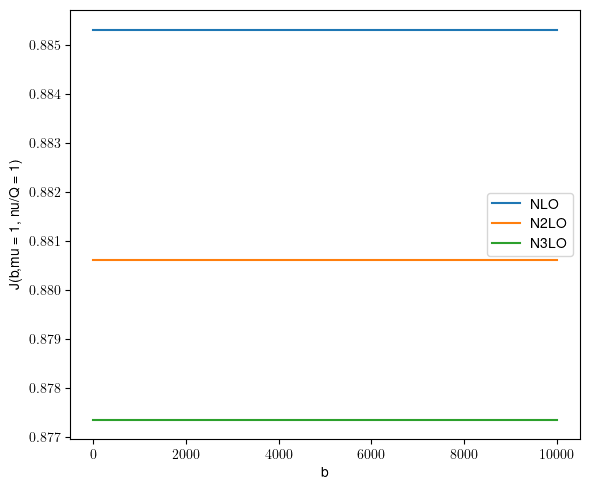

In [21]:
length = 1000

J_1 = np.zeros(length)
J_2 = np.zeros(length)
J_3 = np.zeros(length)

b0 = 1.12292
b_list = np.linspace(0.1,10000,length)

for index, bp in enumerate(b_list):
    J_1[index] = Main.J_func(b=bp, μJ = b0/bp, νdQ=1.0, αs=0.118, order=1, nf=5)
    J_2[index] = Main.J_func(b=bp, μJ = b0/bp, νdQ=1.0, αs=0.118, order=2, nf=5)
    J_3[index] = Main.J_func(b=bp, μJ = b0/bp, νdQ=1.0, αs=0.118, order=3, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, J_1, label="NLO")
ax1.plot(b_list, J_2, label="N2LO")
ax1.plot(b_list, J_3, label="N3LO")
ax1.set_xlabel('b')
ax1.set_ylabel('J(b,mu = 1, nu/Q = 1)')
ax1.legend()

plt.tight_layout()  
plt.show()

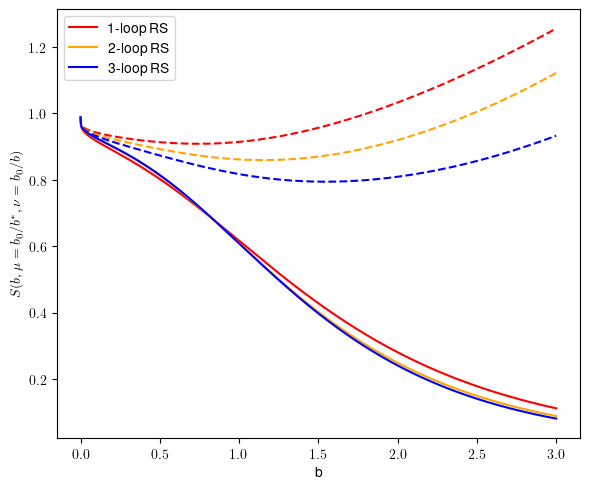

In [5]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)

w_1 = np.zeros(length)
w_2 = np.zeros(length)
w_3 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-9),3,length)

α_list = np.zeros(length)
bstar_list = np.zeros(length)

for index, bp in enumerate(b_list):
    bstar_list[index] = bp/(1+(bp/b0)**2)**0.5
    α_list[index] = Main.alpha_s_func(μf=b0/bstar_list[index], μi=91.1876, αs=0.118, order = 4, nf=5)

for index, bp in enumerate(b_list):
    v_1[index] = Main.S_renormalon_func(b=bp, μS = b0/bstar_list[index], νS=b0/bp, αs=α_list[index] , order=1, nf=5)
    v_2[index] = Main.S_renormalon_func(b=bp, μS = b0/bstar_list[index], νS=b0/bp, αs=α_list[index] , order=2, nf=5)
    v_3[index] = Main.S_renormalon_func(b=bp, μS = b0/bstar_list[index], νS=b0/bp, αs=α_list[index] , order=3, nf=5)

    w_1[index] = Main.S_func(b=bp, μS = b0/bstar_list[index], νS=b0/bp, αs=α_list[index] , order=1, nf=5)
    w_2[index] = Main.S_func(b=bp, μS = b0/bstar_list[index], νS=b0/bp, αs=α_list[index] , order=2, nf=5)
    w_3[index] = Main.S_func(b=bp, μS = b0/bstar_list[index], νS=b0/bp, αs=α_list[index] , order=3, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop RS", color="red")
ax1.plot(b_list, v_2, label="2-loop RS", color="orange")
ax1.plot(b_list, v_3, label="3-loop RS", color="blue")

ax1.plot(b_list, w_1, linestyle='dashed', color="red")
ax1.plot(b_list, w_2, linestyle='dashed', color="orange")
ax1.plot(b_list, w_3, linestyle='dashed', color="blue")

ax1.set_xlabel('b')
ax1.set_ylabel(r"\rm $ S(b,\mu=b_0/b^*,\nu=b_0/b) $")
ax1.legend()

plt.tight_layout()  
plt.show()

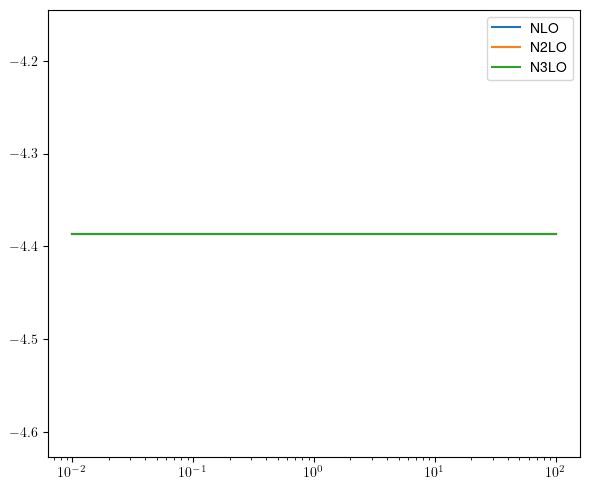

In [27]:
length = 1000

S_1 = np.zeros(length)
S_2 = np.zeros(length)
S_3 = np.zeros(length)

b0 = 1.12292
nu_list = np.linspace(0.01,100,length)

for index, nu in enumerate(nu_list):
    S_1[index] = Main.S1_func(0,np.log((1/b0)**2/(nu**2)),5)
    S_2[index] =  Main.S1_func(0,np.log((1/b0)**2/(nu**2)),5)
    S_3[index] = Main.S1_func(0,np.log((1/b0)**2/(nu**2)),5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(nu_list, S_1, label="NLO")
ax1.plot(nu_list, S_2, label="N2LO")
ax1.plot(nu_list, S_3, label="N3LO")
#ax1.set_xlabel('1/ν^2')
#ax1.set_ylabel('S(b = b0, mu = b0/b, nu)')
ax1.legend()
ax1.set_xscale('log')  
plt.tight_layout()  
plt.show()

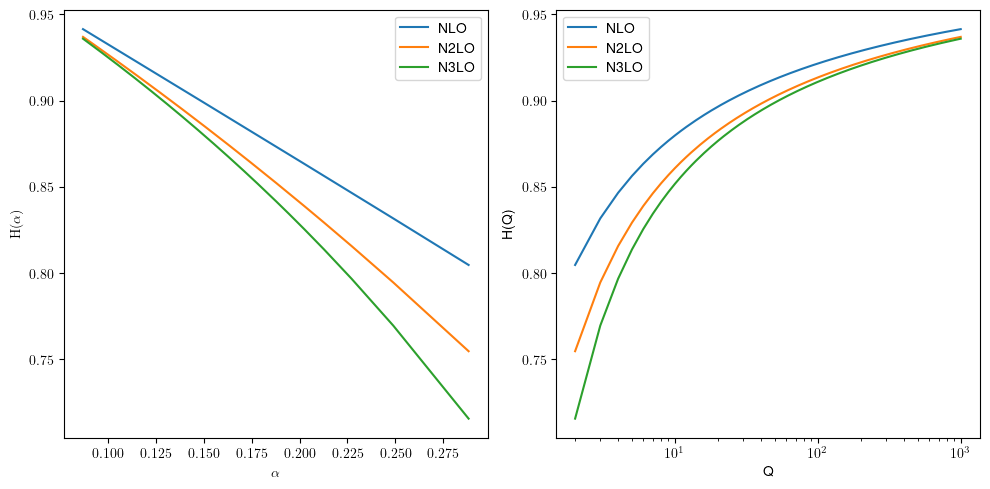

In [25]:
length = len(alpha_3)
H_1 = np.zeros(length)
H_2 = np.zeros(length)
H_3 = np.zeros(length)

for index, alpha_value in enumerate(alpha_4):
    H_1[index] = Main.H_func(μH=float(1*q_value)**2.0, Q=float(q_value)**2.0, αs=float(alpha_value), order=1)
    H_2[index] = Main.H_func(μH=float(1*q_value)**2.0, Q=float(q_value)**2.0, αs=float(alpha_value), order=2)
    H_3[index] = Main.H_func(μH=float(1*q_value)**2.0, Q=float(q_value)**2.0, αs=float(alpha_value), order=3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) 

ax1.plot(alpha_3, H_1, label="NLO")
ax1.plot(alpha_3, H_2, label="N2LO")
ax1.plot(alpha_3, H_3, label="N3LO")
ax1.set_xlabel(r"\rm $\alpha$")
ax1.set_ylabel(r"\rm H($\alpha$)")
ax1.legend()

ax2.plot(Q, H_1, label="NLO")
ax2.plot(Q, H_2, label="N2LO")
ax2.plot(Q, H_3, label="N3LO")
ax2.set_xlabel('Q')
ax2.set_ylabel('H(Q)')
ax2.set_xscale('log')  
ax2.legend()

plt.tight_layout()  
plt.show()

In [86]:
cT1 = Main.cT1_func(5)
cT2 = Main.cT2_func(5)
cT3 = Main.cT3_func(5)
print(np.exp((0.118/(4*(np.pi)))*cT1))
print(np.exp((0.118/(4*(np.pi)))*cT1+(0.118/(4*(np.pi)))**2*cT2))
print(np.exp((0.118/(4*(np.pi)))*cT1+(0.118/(4*(np.pi)))**2*cT2+(0.118/(4*(np.pi)))**3*cT3))

0.9596470978487073
0.9569821949893775
0.9553964894682108
